In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [49]:
## Import the data from the csv
data = pd.read_csv("/Users/sujoy7471/Desktop/TIFR/4th Sem/Astro2/Observations/FinalData.csv", delimiter = ",", skiprows = 2)
jd = data.iloc[:, 0].to_numpy()

io = data.iloc[:, 1].to_numpy()
io_err = data.iloc[:, 2].to_numpy()

callistro = data.iloc[:, 3].to_numpy()
callistro_err = data.iloc[:, 4].to_numpy()

ganymide = data.iloc[:, 5].to_numpy()
ganymide_err = data.iloc[:, 6].to_numpy()

europa = data.iloc[:, 7].to_numpy()
europa_err = data.iloc[:, 8].to_numpy()

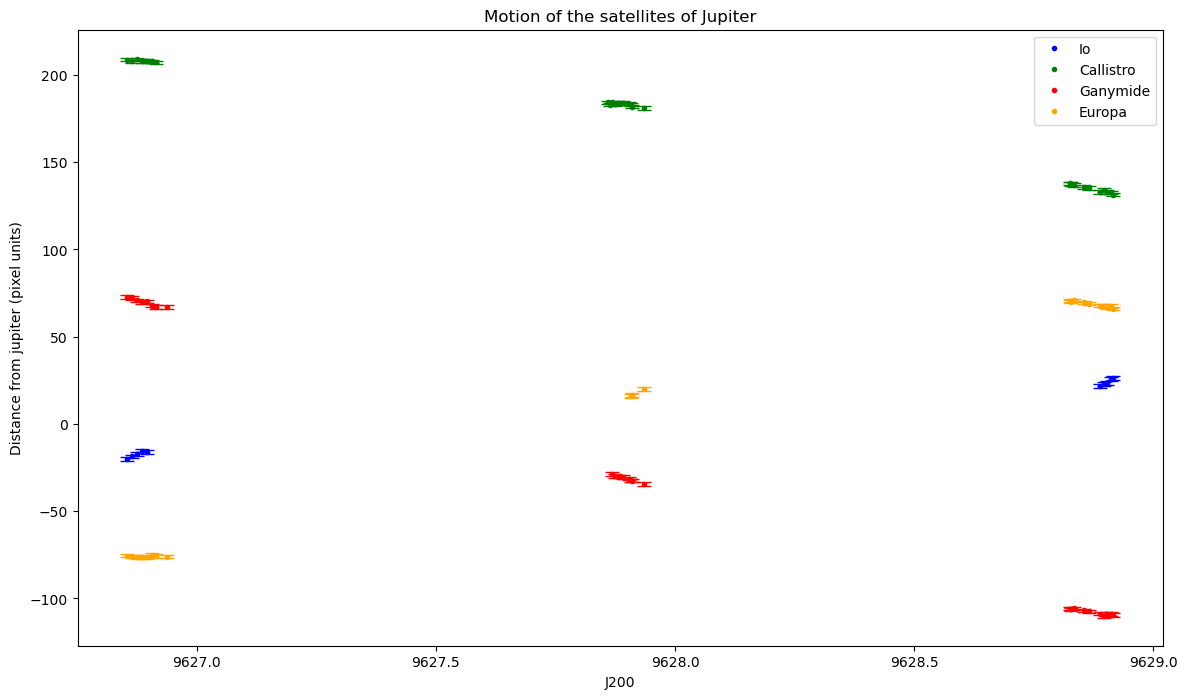

In [50]:
## Rough plot to see the behaviour
plt.figure(figsize = (14, 8))

plt.plot(jd, io, '.', label = "Io", color = "b")
plt.errorbar(jd, io, yerr=io_err, fmt='none', capsize=5, color = "b")

plt.plot(jd, callistro, '.', label = "Callistro", color = 'g')
plt.errorbar(jd, callistro, yerr=callistro_err, fmt='none', capsize=5, color = 'g')

plt.plot(jd, ganymide, '.', label = "Ganymide", color = "r")
plt.errorbar(jd, ganymide, yerr=ganymide_err, fmt='none', capsize=5, color = "r")

plt.plot(jd, europa, '.', label = "Europa", color = "orange")
plt.errorbar(jd, europa  , yerr=europa_err, fmt='none', capsize=5, color = "orange")

plt.xlabel("J200")
plt.ylabel("Distance from jupiter (pixel units)")
plt.title("Motion of the satellites of Jupiter")
plt.legend()
plt.show()

## Fitting a sine curve and extracting parameters

In [51]:
## Define the sine function
def sine_model(x, A, omega, phi):
        return A * np.sin(omega * x + phi)

## Define the fitting function
def fit(x, y, yerr, bounds_omega, bound_a = np.array([-200, 200]), bound_phi = np.array([-np.pi, np.pi])):
    def sine_model(x, A, omega, phi):
        return A * np.sin(omega * x + phi)


    mask = ~np.isnan(y) & ~np.isnan(yerr)
    x_p = x[mask]
    x_prime = x_p
    y_prime = y[mask]
    yerr_prime = yerr[mask]


    bounds = ([bound_a[0], bounds_omega[0], bound_phi[0]], [bound_a[1], bounds_omega[1], bound_phi[1]])

    popt, pcov = curve_fit(sine_model, x_prime, y_prime, sigma = yerr_prime, absolute_sigma=True, maxfev = 100000, bounds = bounds)

    return popt, pcov

Parameters for Io:
Amplitude: -52.293 ± 0.873 pixels
Time Period: 1.795 ± 0.032 days


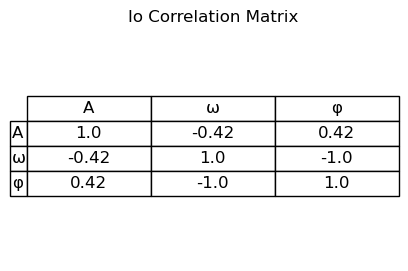

Parameters for Europa:
Amplitude: -74.514 ± 1.845 pixels
Time Period: 3.590 ± 0.037 days


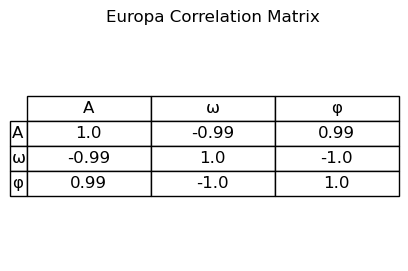



Parameters for Ganymide:
Amplitude: 110.995 ± 0.344 pixels
Time Period: 6.280 ± 0.072 days


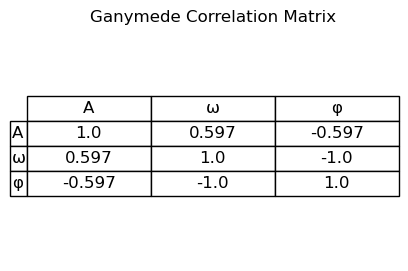



Parameters for Callistro:
Amplitude: 207.637 ± 0.546 pixels
Time Period: 15.711 ± 0.210 days


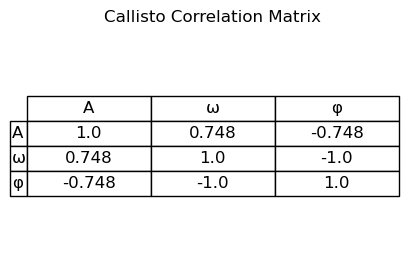

In [52]:
##_________________Perform the fitting__________________
##Io
bound_omega_io = np.array([3, 4])

popt_io, pcov_io = fit(jd, io, io_err, bound_omega_io)

print("Parameters for Io:")
print(f"Amplitude: {popt_io[0]:0.3f} ± {np.sqrt(pcov_io[0,0]):0.3f} pixels")

T_io = 2*np.pi/popt_io[1]
sigma_T_io = (2*np.pi/popt_io[1]**2) * np.sqrt(pcov_io[1,1])

print(f"Time Period: {T_io:0.3f} ± {sigma_T_io:0.3f} days")

corr_io = pcov_io / np.outer(
    np.sqrt(np.diag(pcov_io)),
    np.sqrt(np.diag(pcov_io))
)

fig, ax = plt.subplots(figsize=(4,3))
ax.axis('off')

table = ax.table(
    cellText=np.round(corr_io,3),
    rowLabels=["A","ω","φ"],
    colLabels=["A","ω","φ"],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2,1.5)

for cell in table.get_celld().values():
    cell.set_facecolor('white')
    cell.set_edgecolor('black')

plt.title("Io Correlation Matrix")
plt.show()




##Europa
bound_omega_europa = np.array([1.5, 2])

popt_europa, pcov_europa = fit(jd, europa, europa_err, bound_omega_europa)

print("Parameters for Europa:")
print(f"Amplitude: {popt_europa[0]:0.3f} ± {np.sqrt(pcov_europa[0,0]):0.3f} pixels")

T_europa = 2*np.pi/popt_europa[1]
sigma_T_europa = (2*np.pi/popt_europa[1]**2) * np.sqrt(pcov_europa[1,1])

print(f"Time Period: {T_europa:0.3f} ± {sigma_T_europa:0.3f} days")

corr_europa = pcov_europa / np.outer(
    np.sqrt(np.diag(pcov_europa)),
    np.sqrt(np.diag(pcov_europa))
)

fig, ax = plt.subplots(figsize=(4,3))
ax.axis('off')

table = ax.table(
    cellText=np.round(corr_europa,3),
    rowLabels=["A","ω","φ"],
    colLabels=["A","ω","φ"],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2,1.5)

for cell in table.get_celld().values():
    cell.set_facecolor('white')
    cell.set_edgecolor('black')

plt.title("Europa Correlation Matrix")
plt.show()
print("\n")


##Ganymide
bound_omega_ganymide = np.array([0, 2])

popt_ganymide, pcov_ganymide = fit(jd, ganymide, ganymide_err, bound_omega_ganymide)

print("Parameters for Ganymide:")
print(f"Amplitude: {popt_ganymide[0]:0.3f} ± {np.sqrt(pcov_ganymide[0,0]):0.3f} pixels")

T_ganymide = 2*np.pi/popt_ganymide[1]
sigma_T_ganymide = (2*np.pi/popt_ganymide[1]**2) * np.sqrt(pcov_ganymide[1,1])

print(f"Time Period: {T_ganymide:0.3f} ± {sigma_T_ganymide:0.3f} days")

corr_ganymide = pcov_ganymide / np.outer(
    np.sqrt(np.diag(pcov_ganymide)),
    np.sqrt(np.diag(pcov_ganymide))
)

fig, ax = plt.subplots(figsize=(4,3))
ax.axis('off')

table = ax.table(
    cellText=np.round(corr_ganymide,3),
    rowLabels=["A","ω","φ"],
    colLabels=["A","ω","φ"],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2,1.5)

for cell in table.get_celld().values():
    cell.set_facecolor('white')
    cell.set_edgecolor('black')

plt.title("Ganymede Correlation Matrix")
plt.show()
print("\n")



##Callistro
bound_omega_callistro = np.array([0.3, 0.5])
bound_a_callistro = np.array([200, 250])
bound_phi_callistro = np.array([0, np.pi])

popt_callistro, pcov_callistro = fit(
    jd,
    callistro,
    callistro_err,
    bound_omega_callistro,
    bound_a=bound_a_callistro,
    bound_phi = bound_phi_callistro

)

print("Parameters for Callistro:")
print(f"Amplitude: {popt_callistro[0]:0.3f} ± {np.sqrt(pcov_callistro[0,0]):0.3f} pixels")

T_callistro = 2*np.pi/popt_callistro[1]
sigma_T_callistro = (2*np.pi/popt_callistro[1]**2) * np.sqrt(pcov_callistro[1,1])

print(f"Time Period: {T_callistro:0.3f} ± {sigma_T_callistro:0.3f} days")

corr_callistro = pcov_callistro / np.outer(
    np.sqrt(np.diag(pcov_callistro)),
    np.sqrt(np.diag(pcov_callistro))
)

fig, ax = plt.subplots(figsize=(4,3))
ax.axis('off')

table = ax.table(
    cellText=np.round(corr_callistro,3),
    rowLabels=["A","ω","φ"],
    colLabels=["A","ω","φ"],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2,1.5)

for cell in table.get_celld().values():
    cell.set_facecolor('white')
    cell.set_edgecolor('black')

plt.title("Callisto Correlation Matrix")
plt.show()
print("\n")

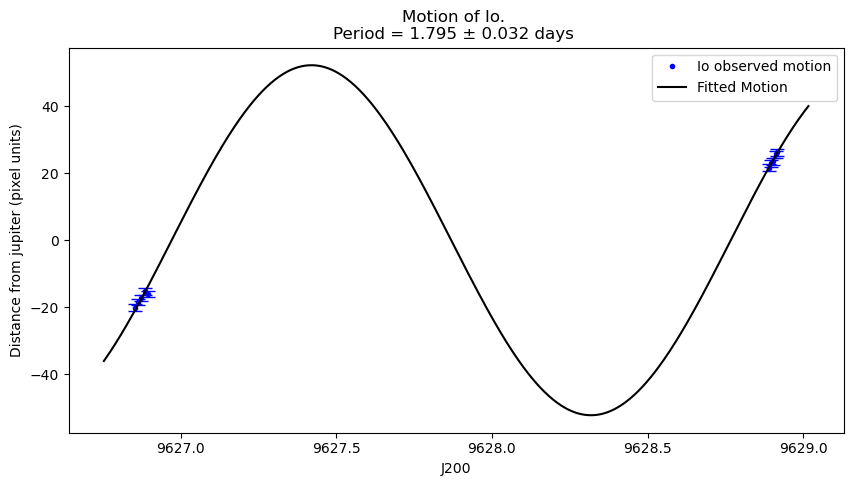

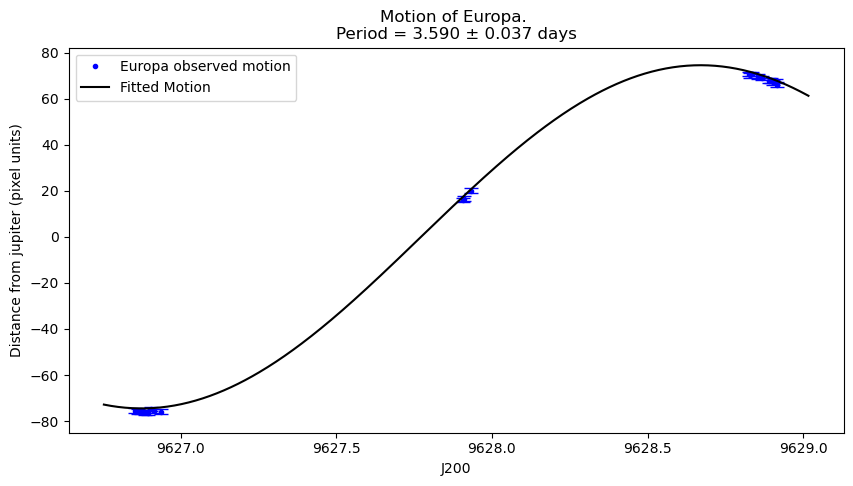

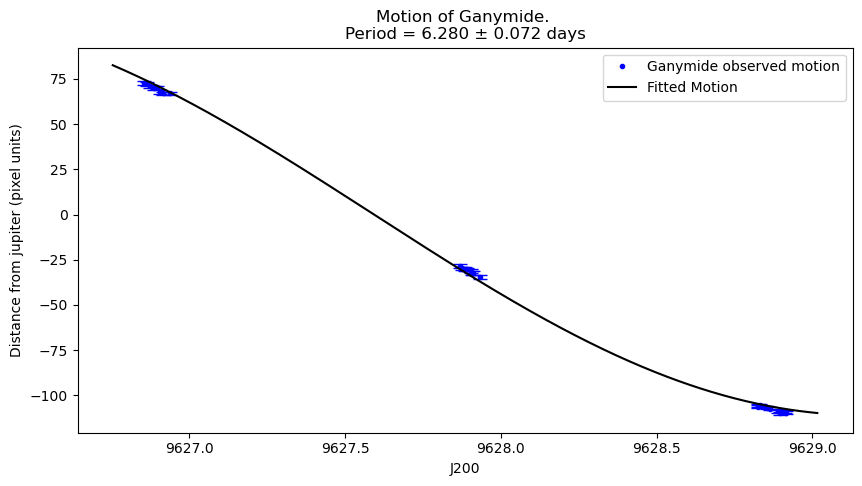

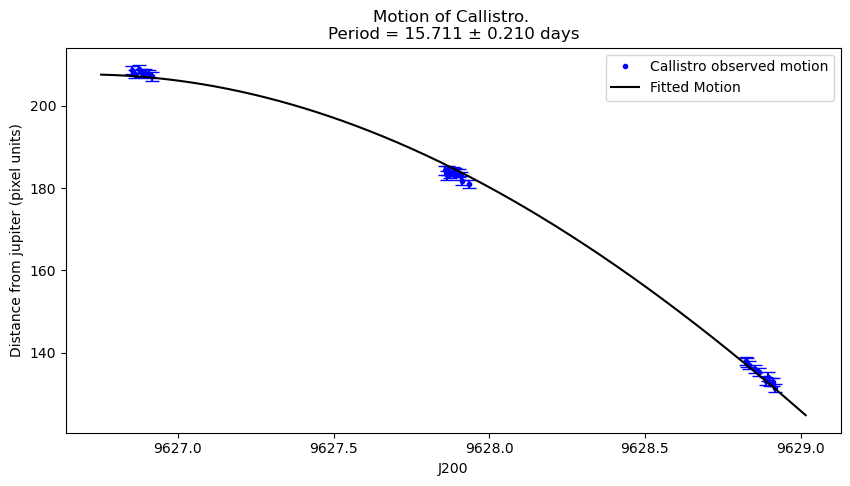

In [53]:
## Plot the fitted curves on the data
x = np.linspace(jd[0]- 0.1, jd[-1] + 0.1, 500)

## For Io
plt.figure(figsize = (10, 5))

plt.plot(jd, io, '.', label = "Io observed motion", color = "b")
plt.errorbar(jd, io, yerr=io_err, fmt='none', capsize=5, color = "b")
plt.plot(x, sine_model(x, *popt_io), color = "k", label = "Fitted Motion")
plt.xlabel("J200")
plt.ylabel("Distance from jupiter (pixel units)")
plt.title(f"Motion of Io. \nPeriod = {T_io:0.3f} ± {sigma_T_io:0.3f} days ")
plt.legend()
plt.show()


## For Europa
plt.figure(figsize = (10, 5))
plt.plot(jd, europa, '.', label = "Europa observed motion", color = 'b')
plt.errorbar(jd, europa, yerr=europa_err, fmt='none', capsize=5, color = 'b')
plt.plot(x, sine_model(x, *popt_europa), color = "k", label = "Fitted Motion")
plt.xlabel("J200")
plt.ylabel("Distance from jupiter (pixel units)")
plt.title(f"Motion of Europa. \nPeriod = {T_europa:0.3f} ± {sigma_T_europa:0.3f} days")
plt.legend()
plt.show()

## For Ganymide
plt.figure(figsize = (10, 5))
plt.plot(jd, ganymide, '.', label = "Ganymide observed motion", color = 'b')
plt.errorbar(jd, ganymide, yerr=ganymide_err, fmt='none', capsize=5, color = 'b')
plt.plot(x, sine_model(x, *popt_ganymide), color = "k", label = "Fitted Motion")
plt.xlabel("J200")
plt.ylabel("Distance from jupiter (pixel units)")
plt.title(f"Motion of Ganymide. \nPeriod = {T_ganymide:0.3f} ± {sigma_T_ganymide:0.3f} days")
plt.legend()
plt.show()

## For Callistro
plt.figure(figsize = (10, 5))
plt.plot(jd, callistro, '.', label = "Callistro observed motion", color = 'b')
plt.errorbar(jd, callistro, yerr=callistro_err, fmt='none', capsize=5, color = 'b')
plt.plot(x, sine_model(x, *popt_callistro), color = "k", label = "Fitted Motion")
plt.xlabel("J200")
plt.ylabel("Distance from jupiter (pixel units)")
plt.title(f"Motion of Callistro. \nPeriod = {T_callistro:0.3f} ± {sigma_T_callistro:0.3f} days")
plt.legend()
plt.show()



## Measurement of the mass of jupiter

#### Here I am taking the radii of the orbits of the sattelites from literature:
* $R_{Io}$ = 421700000 m
* $R_{Europa}$ = 671100000 m
* $R_{Ganymede}$ = 1070400000 m
* $R_{Callistro}$ = 1882700000 m

In [56]:
## Define the function
def mass_function(T, T_err, r, r_err = 0):
    G = 6.6743e-11
    M = (4*np.pi**2 * r**3) / (G * (T*86400)**2)
    err_M = M * np.sqrt( (3*r_err/r)**2 + (2*T_err/T)**2)
    return M, err_M


## Measure the mass using the four sattelites
### Io
M_j_io, M_j_err_io = mass_function(1.795, 0.032, 421700000)
print(f"Measured mass of Jupiter using Io is: {M_j_io:0.3e} ± {M_j_err_io:0.3e} Kg")

### Europa
M_j_europa, M_j_err_europa = mass_function(3.590, 0.037, 671100000)
print(f"Measured mass of Jupiter using Europa is: {M_j_europa:0.3e} ± {M_j_err_europa:0.3e} Kg")

### Ganymide
M_j_ganymide, M_j_err_ganymide = mass_function(6.280, 0.072, 1070400000)
print(f"Measured mass of Jupiter using Ganymide is: {M_j_ganymide:0.3e} ± {M_j_err_ganymide:0.3e} Kg")

### Callistro
M_j_callistro, M_j_err_callistro = mass_function(15.711 , 0.210, 1882700000)
print(f"Measured mass of Jupiter using Callistro is: {M_j_callistro:0.3e} ± {M_j_err_callistro:0.3e} Kg")

Measured mass of Jupiter using Io is: 1.844e+27 ± 6.575e+25 Kg
Measured mass of Jupiter using Europa is: 1.858e+27 ± 3.830e+25 Kg
Measured mass of Jupiter using Ganymide is: 2.464e+27 ± 5.650e+25 Kg
Measured mass of Jupiter using Callistro is: 2.142e+27 ± 5.727e+25 Kg


In [58]:
## calculating the average mass
## Using only Io and Europa, as for the other 2, the data does not cover significant period
M = np.array([1.844e27, 1.858e27])
sigma = np.array([6.575e25, 3.830e25])

# M = np.array([1.844e27, 1.858e27, 2.464e+27, 2.142e+27])
# sigma = np.array([6.575e25, 3.830e25, 5.650e+25, 5.727e+25])

w = 1/sigma**2

M_avg = np.sum(w*M)/np.sum(w)
sigma_avg = 1/np.sqrt(np.sum(w))

print(f"The measured mass of the Jupiter is: = {M_avg:.3e} ± {sigma_avg:.3e} kg")

The measured mass of the Jupiter is: = 1.854e+27 ± 3.309e+25 kg
